##2.Data Collection

###Import Necessary Libraries

In [ ]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential,load_model
from keras.layers import Conv2D,MaxPool2D,UpSampling2D
import warnings
warnings.filterwarnings('ignore')

###Load Data

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


##3.Data Preparation

In [ ]:
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

###Resize the image

In [ ]:
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

###Normalize image

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

print(X_train.min(),X_train.max())
print(X_test.min(),X_test.max())

0.0 1.0
0.0 1.0


###Add Noise

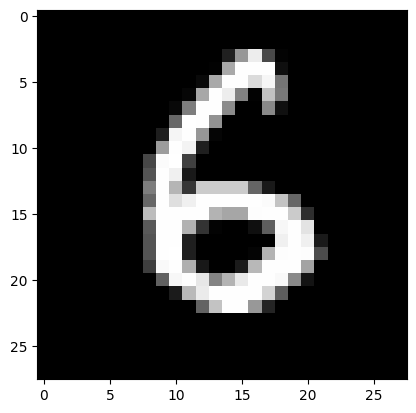

In [ ]:
plt.imshow(X_train[106],cmap='gray')

In [ ]:
X_train_noise = X_train + 0.2 * np.random.normal(loc=0.0,scale=1.0,size=X_train.shape)
X_test_noise = X_test + 0.2 * np.random.normal(loc=0.0,scale=1.0,size=X_test.shape)

In [ ]:
print(X_train_noise.min(),X_train.max())
X_test_noise.min(),X_test_noise.max()

-1.0636965726064642 1.0


(np.float64(-1.0469779348342751), np.float64(1.95572847331895))

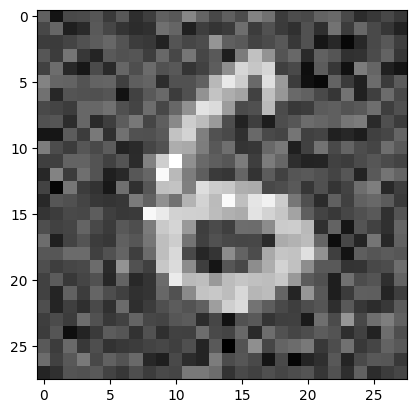

In [ ]:
plt.imshow(X_train_noise[106],cmap='gray')

###Add Clip to make every pixel as postive

In [ ]:
X_train_clipped = np.clip(a=X_train_noise,a_min=0.,a_max=1.)
X_test_clipped = np.clip(a=X_test_noise,a_min=0.,a_max=1.)

In [ ]:
X_train_clipped.min(),X_train_clipped.max()

(np.float64(0.0), np.float64(1.0))

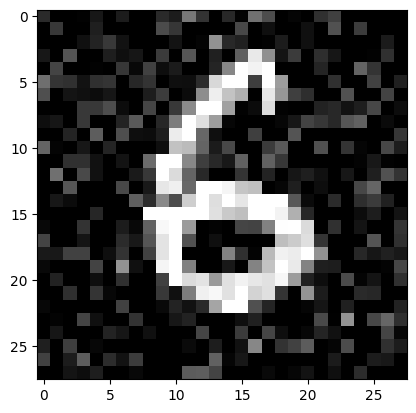

In [ ]:
plt.imshow(X_train_clipped[106],cmap='gray')

###4.Model Building- Autoencoders

In [ ]:
model = Sequential()
##Encoders - compress
model.add(Conv2D(filters= 32,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu',input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(filters= 8,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

##Decoders - expands
model.add(Conv2D(filters=8,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.add(UpSampling2D(size=(2,2)))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.add(UpSampling2D(size=(2,2)))
model.add(Conv2D(filters=1,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         2,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,841 (22.82 KB)

 Trainable params: 5,841 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

###Model Compilatation

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['accuracy'])

###5.Model Training

In [ ]:
model.fit(X_train_clipped,X_train,batch_size=32,epochs=10,validation_data=(X_test_clipped,X_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8138 - loss: 0.0110 - val_accuracy: 0.8139 - val_loss: 0.0072
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8148 - loss: 0.0065 - val_accuracy: 0.8138 - val_loss: 0.0060
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8149 - loss: 0.0058 - val_accuracy: 0.8141 - val_loss: 0.0055
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8150 - loss: 0.0055 - val_accuracy: 0.8140 - val_loss: 0.0052
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8151 - loss: 0.0052 - val_accuracy: 0.8142 - val_loss: 0.0051
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8151 - loss: 0.0051 - val_accuracy: 0.8142 - val_loss: 0.0049
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8151 - loss: 0.0050 - val_accuracy: 0.8141 - val_loss: 0.0048
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8152 - loss: 0.0048 -

###Model Evaluation

In [ ]:
print(model.evaluate(X_test_clipped,X_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8142 - loss: 0.0046
[0.004627877846360207, 0.8142351508140564]


##6.Model Testing

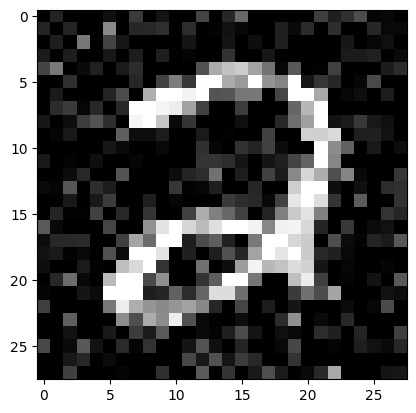

In [ ]:
plt.imshow(X_test_clipped[106],cmap='gray')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


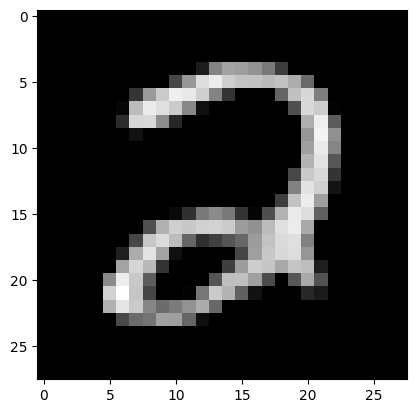

In [ ]:
y_pred = model.predict(X_test_clipped)
plt.imshow(y_pred[106],cmap='gray')

##Save the Intelligence

In [ ]:
model.save('denoised.h5')

###Clear Representation of Unseen Data

In [ ]:
denoise_intel =  load_model('denoised.h5')

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step


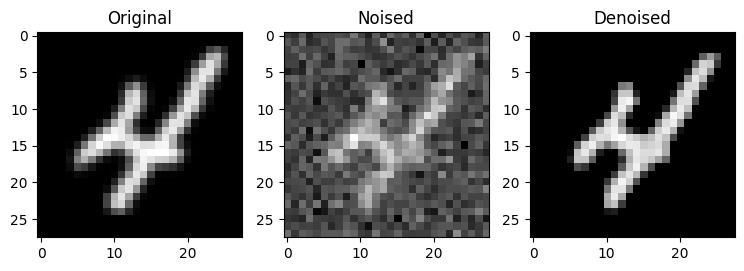

In [ ]:
from PIL import Image,ImageOps
image_path ='/content/Screenshot 2026-07-24 221828.png'
image = Image.open(image_path).convert(mode='L').resize(size=(28,28))
# image = ImageOps.invert(image)
image = np.array(image)
image = image.reshape(1,28,28,1)
print(image.shape)
image = image/255.0
image_noised = image + 0.2 * np.random.normal(loc=0.0,scale=1.0,size=image.shape)
image_clipped = np.clip(a=image_noised,a_min=0.,a_max=1.)
pred = denoise_intel.predict(image_clipped)

plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.imshow(image[0,:,:,0],cmap='gray')
plt.title('Original')

plt.subplot(1,3,2)
plt.imshow(image_noised[0,:,:,0],cmap='gray')
plt.title('Noised')

plt.subplot(1,3,3)
plt.imshow(pred[0,:,:,0],cmap='gray')
plt.title('Denoised')
plt.show()